# Using TLEs, vs using SPICE kernels

TLE's are generated for Pandora multiple times a day. These capture the instantaneous state of Pandora. TLE's are useful for predicting future positions for Pandora, because they can be propagated forward. 

The SPK and CK SPICE kernels that `PandoraSpacecraft` uses are compressed/interpolated versions of the actual spacecraft bus telemetry, and so capture the "historical truth" of Pandora's state.

You can use `PandoraSpacecraft` in two modes:

1. **Default Mode**: This is the mode where `PandoraSpacecraft` will use the SPICE kernels made from the historical spacecraft bus telemetry. This can only be known in the past, but gives the as measured position, velocity, and pointing.
2. **TLE Only Mode**: This mode uses only the TLEs for the spacecraft. TLEs are considered "valid" for two days, and the most recent TLE is propagated for 1 year. This means that in this mode you are able to predict the future position of Pandora, but you are unable to access any pointing information.

Below we show how to switch modes, and the different altitudes obtained in the different modes

!!! warning `PandoraSpacecraft` may be innaccurate

    The SPICE kernels for `PandoraSpacecraft` are built from recorded bus telemetry, which in some instances can be misreported or contain outliers/unphysical points. We endeavour to remove those times from the kernels, but some may remain. As such, the SPK and CK kernels are evaluated everywhere, but you should check they are physical in your analysis.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandoraspacecraft as psc

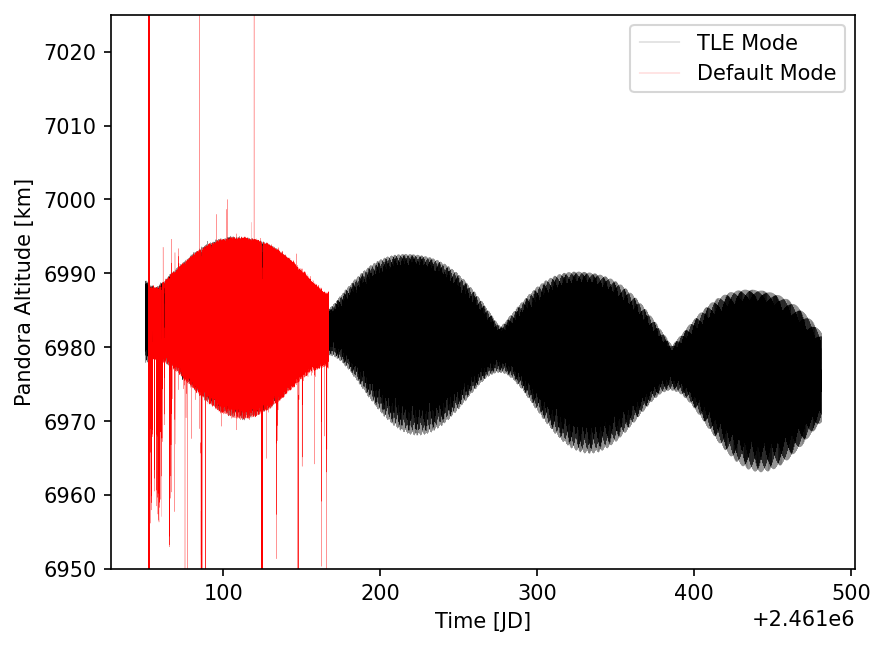

In [50]:
fig, ax = plt.subplots(dpi=150, facecolor='white')
# Use TLE Mode
ps = psc.PandoraSpacecraft(tles_only=True)
t = Time(np.linspace(ps.start_time.jd + 0.01, ps.end_time.jd - 0.01, 10000), format='jd')
alt = ps.get_altitude(t)
ax.plot(t.jd, alt.value, lw=0.1, c='k', label='TLE Mode')

# Use the default mode
ps = psc.PandoraSpacecraft()
t = Time(np.linspace(ps.start_time.jd + 0.01, ps.end_time.jd - 0.01, 10000), format='jd')
alt = ps.get_altitude(t)

ax.plot(t.jd, alt.value, lw=0.1, c='r', label='Default Mode')
ax.set(ylim=(6950, 7025), xlabel='Time [JD]', ylabel='Pandora Altitude [km]')
ax.legend()